In [6]:
url = "https://raw.githubusercontent.com/LearnDataSci/articles/master/Python%20Pandas%20Tutorial%20A%20Complete%20Introduction%20for%20Beginners/IMDB-Movie-Data.csv"
df = pd.read_csv(url)
print(df.shape)

(1000, 12)


In [7]:
print(df.columns.tolist())

['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year', 'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)', 'Metascore']


In [8]:
print(df.dtypes)
print("\nNulos:\n", df.isnull().sum())
print("\nEstatísticas:\n", df.describe())

Rank                    int64
Title                  object
Genre                  object
Description            object
Director               object
Actors                 object
Year                    int64
Runtime (Minutes)       int64
Rating                float64
Votes                   int64
Revenue (Millions)    float64
Metascore             float64
dtype: object

Nulos:
 Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

Estatísticas:
               Rank         Year  Runtime (Minutes)       Rating         Votes  \
count  1000.000000  1000.000000        1000.000000  1000.000000  1.000000e+03   
mean    500.500000  2012.783000         113.172000     6.723200  1.698083e+05   
std     288.819436     3.205962  

In [9]:
# LIMPEZA
df['Revenue (Millions)'] = df['Revenue (Millions)'].fillna(df['Revenue (Millions)'].median())
df['Metascore'] = df['Metascore'].fillna(df['Metascore'].median())

# PERGUNTA 1 — Gênero com maior nota média
print("=== Nota média por gênero ===")
print(df.groupby('Genre')['Rating'].mean().sort_values(ascending=False).head(10))

# PERGUNTA 2 — Filmes mais lucrativos
print("\n=== Top 10 filmes por receita ===")
print(df[['Title','Revenue (Millions)','Rating']].sort_values('Revenue (Millions)', ascending=False).head(10))

# PERGUNTA 3 — Diretores com mais filmes
print("\n=== Diretores mais produtivos ===")
print(df['Director'].value_counts().head(10))

# PERGUNTA 4 — Receita média por ano
print("\n=== Receita média por ano ===")
print(df.groupby('Year')['Revenue (Millions)'].mean().round(2))

# PERGUNTA 5 — Relação nota x receita
correlacao = df['Rating'].corr(df['Revenue (Millions)'])
print(f"\n=== Correlação Nota x Receita: {correlacao:.2f} ===")

# PERGUNTA 6 — Filmes acima de 8.0 de nota
tops = df[df['Rating'] >= 8.0][['Title','Rating','Revenue (Millions)','Genre']]
print(f"\n=== Filmes nota 8+ ({len(tops)} filmes) ===")
print(tops.sort_values('Rating', ascending=False))

=== Nota média por gênero ===
Genre
Animation,Drama,Fantasy       8.60
Drama,Family,Music            8.50
Drama,Western                 8.40
Animation,Drama,Romance       8.40
Adventure,Drama,Sci-Fi        8.30
Adventure,Drama,War           8.30
Drama,Fantasy,War             8.20
Drama,Mystery,War             8.20
Biography,Comedy,Crime        8.20
Animation,Adventure,Family    8.15
Name: Rating, dtype: float64

=== Top 10 filmes por receita ===
                                          Title  Revenue (Millions)  Rating
50   Star Wars: Episode VII - The Force Awakens              936.63     8.1
87                                       Avatar              760.51     7.8
85                               Jurassic World              652.18     7.0
76                                 The Avengers              623.28     8.1
54                              The Dark Knight              533.32     9.0
12                                    Rogue One              532.17     7.9
119               

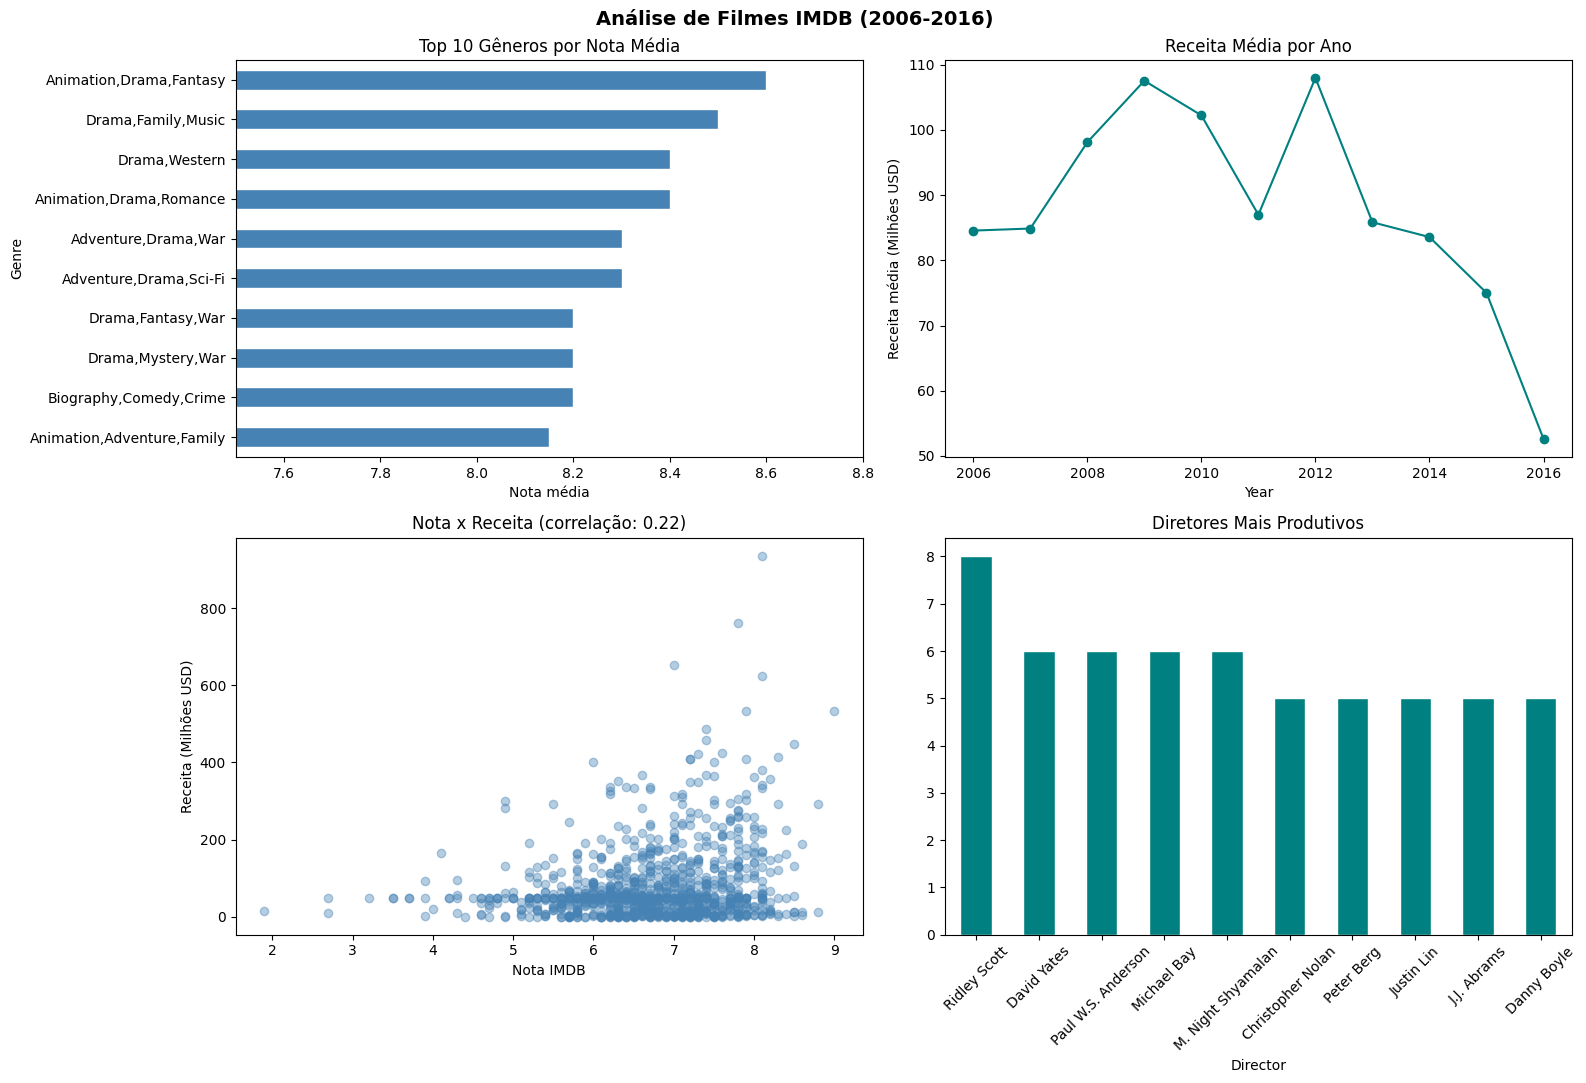

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Análise de Filmes IMDB (2006-2016)', fontsize=14, fontweight='bold')

# Gráfico 1 — CORRIGIDO: ordem certa e eixo ajustado
top_generos = df.groupby('Genre')['Rating'].mean().sort_values(ascending=True).tail(10)
top_generos.plot(kind='barh', ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Top 10 Gêneros por Nota Média')
axes[0,0].set_xlabel('Nota média')
axes[0,0].set_xlim(7.5, 8.8)  # zoom no eixo para ver diferença entre barras

# Gráfico 2 — Receita por ano (estava bom)
df.groupby('Year')['Revenue (Millions)'].mean().plot(
    kind='line', ax=axes[0,1], color='teal', marker='o')
axes[0,1].set_title('Receita Média por Ano')
axes[0,1].set_ylabel('Receita média (Milhões USD)')

# Gráfico 3 — Nota x Receita
axes[1,0].scatter(df['Rating'], df['Revenue (Millions)'], alpha=0.4, color='steelblue')
axes[1,0].set_title('Nota x Receita (correlação: 0.22)')
axes[1,0].set_xlabel('Nota IMDB')
axes[1,0].set_ylabel('Receita (Milhões USD)')

# Gráfico 4 — Top diretores
df['Director'].value_counts().head(10).plot(
    kind='bar', ax=axes[1,1], color='teal', edgecolor='white')
axes[1,1].set_title('Diretores Mais Produtivos')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()